In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

MAE 52.50246597226247
MSE 3933.057012013229
RMSE 62.71408942186141
R2 0.2576548957635231


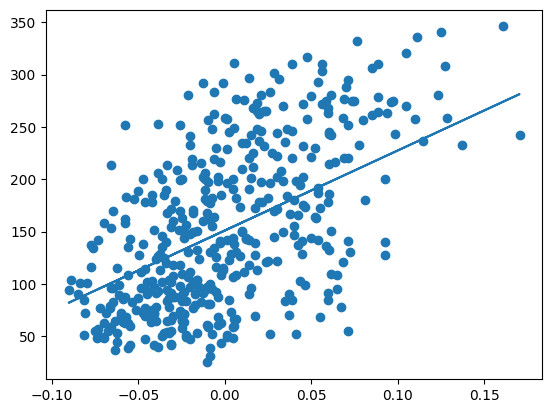

In [38]:
# Linear Regression

data = load_diabetes()
df = pd.DataFrame(data.data, columns=data.feature_names)
x = data.data[:,[2]]
y = data.target

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(x_test,y_test)
y_pred = model.predict(x_test)

print("MAE", mean_absolute_error(y_test,y_pred))
print("MSE", mean_squared_error(y_test,y_pred))
print("RMSE", mean_squared_error(y_test,y_pred)**0.5)
print("R2", r2_score(y_test,y_pred))
plt.scatter(x, y)
plt.plot(x,model.predict(x))
plt.show()

MAE: 50.01881754472502
MSE: 3756.8366496443828
RMSE: 61.2930391614283
R2: 0.2909156196410876


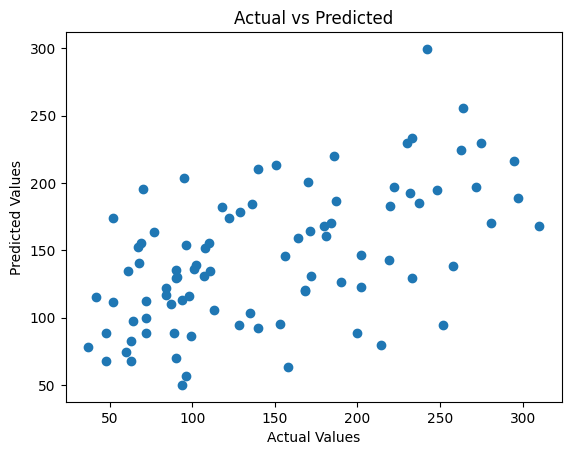

In [ ]:
# Multiple linear regression

x = data.data[:,[0,2,3]]
y = data.target
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)
print("R2:", r2_score(y_test, y_pred))



plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.show()  

MAE: 52.38391176015265
MSE: 4085.025480871632
RMSE: 63.91420406194254
R2: 0.2289715971205667


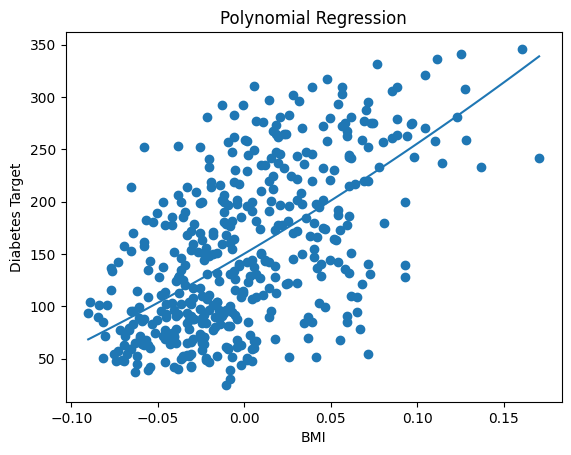

In [44]:
# Polynomial regression

x = data.data[:, [2]]   # BMI
y = data.target

poly = PolynomialFeatures(degree=2)
x_poly = poly.fit_transform(x)
x_train, x_test, y_train, y_test = train_test_split(x_poly,y, test_size=0.2, random_state=42)


model = LinearRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)



print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)
print("R2:", r2_score(y_test, y_pred))

x_line = np.linspace(x.min(), x.max(), 100).reshape(-1, 1)

x_line_poly = poly.transform(X_line)

y_line = model.predict(x_line_poly)

plt.scatter(x, y)
plt.plot(x_line, y_line)
plt.xlabel("BMI")
plt.ylabel("Diabetes Target")
plt.title("Polynomial Regression")
plt.show()

Accuracy: 0.95
Confusion Matrix:
[[12  1]
 [ 0  7]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.92      0.96        13
           1       0.88      1.00      0.93         7

    accuracy                           0.95        20
   macro avg       0.94      0.96      0.95        20
weighted avg       0.96      0.95      0.95        20



c:\Users\jangr\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


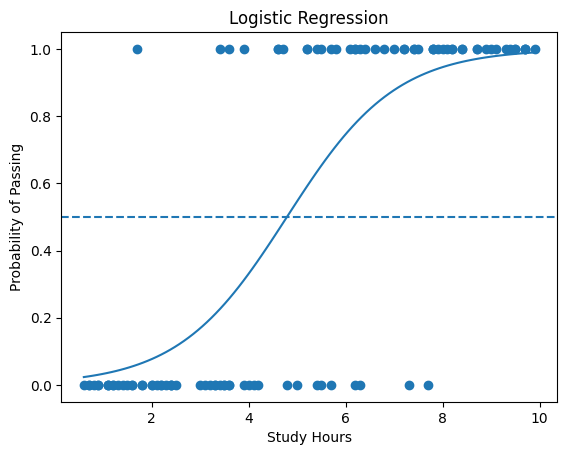

In [ ]:
# Logestic regression

df = pd.read_csv("studyhours.csv")

X = df[["Study_Hours"]]
y = df["Pass"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression()

model.fit(X_train, y_train)


y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))



x_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)

y_prob = model.predict_proba(x_line)[:, 1]

plt.scatter(X, y)
plt.plot(x_line, y_prob)

plt.axhline(0.5, linestyle="--")

plt.xlabel("Study Hours")
plt.ylabel("Probability of Passing")
plt.title("Logistic Regression")

plt.show()

Accuracy: 1.0
Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



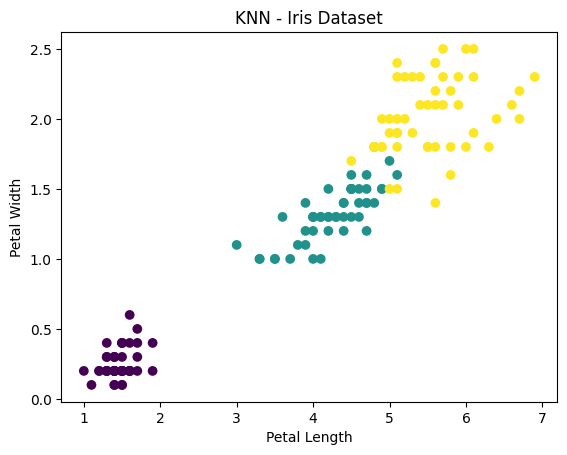

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [54]:
# Knn

df = sns.load_dataset("iris")
X = df[[
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width"
]]
y = df["species"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model = KNeighborsClassifier(n_neighbors=5)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))




plt.scatter(
    df["petal_length"],
    df["petal_width"],
    c=df["species"].astype("category").cat.codes
)

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("KNN - Iris Dataset")
plt.show()

df.head()